# Importing libraries, general variables, and functions

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install system-level tools required for FastQC and Bowtie2
!apt update
!apt install -y fastqc bowtie2
!pip install \
numpy==1.26.4 \
scipy==1.11.4 \
pandas==2.2.2 \
anndata==0.10.8 \
zarr==2.18.2 \
pydeseq2==0.4.12 \
formulaic-contrasts==1.0.0 \
numcodecs==0.15.1 \
cutadapt \
biopython \
pysam

# Refreshes runtime to accommodate for installed system-level tools
import os
os.kill(os.getpid(), 9)

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
166 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tre

In [ ]:
import numpy
import scipy
import pandas
import anndata
import zarr
import pydeseq2

In [ ]:
# Import all necessary libraries
from collections import defaultdict
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from pydeseq2.default_inference import DefaultInference
from formulaic_contrasts import FormulaicContrasts
from Bio import SeqIO
from scipy import stats
import numpy as np
import seaborn as sns
import os
import shutil
import pysam
import pandas as pd
import matplotlib.pyplot as plt
import re

# Functions that are necessary for running DE or candidate substitution analysis or both

In [ ]:
# Expands gz files locally
def expandGZ(inputFiles):
  for files in inputFiles:
    !gunzip {files}

# Run FastQC on a given file (can be trimmed or untrimmed)
def fqstQC(inputFiles, directory):
  # Install FastQC once, if not already installed
  !apt install fastqc -y
  for file_path in inputFiles:
    # Extract the base name of the file
    base_name = os.path.basename(file_path)
    # Create a unique output subdirectory for each file
    output_subdir = os.path.join(directory, f'{base_name}_fastqc_results')
    os.makedirs(output_subdir, exist_ok=True)
    # Run FastQC
    !fastqc {file_path} -o {output_subdir}

# Allows download of a wanted file in local directories
def download_files(inputFiles):
  for files in inputFiles:
    if os.path.exists(files):
        files.download(files)

# Normalization (RPM)
def normalization(number, totalReads):
  number = round((number/totalReads)*(10**6))
  return number

# Moves files to a directory
def moving(inputFiles, directory):
  for files in inputFiles:
    shutil.move(files, directory)

# Extracts group count number from headers
def num_process(query):
  query = int(query.split('x')[-1]) # i.e. Seq1x20, first collapsed group, 20 genes in this group
  return query

# Trims adapters with cutadapt
def trimmer(input_raw_files, adapter, minLength, maxLength, adapter_Mismatch_Num, min_overlap_adapter_length, max_e_errors): ## Input_raw_files gives the input file(s)
  for i in range(len(input_raw_files)):
    output_file = f'trimmed_files_{i+1}_{os.path.basename(input_raw_files[i])}' # Creates names for output trimmed files
    !cutadapt -a {adapter} --max-ee {max_e_errors} -O {min_overlap_adapter_length} -m {minLength} -M {maxLength} -n {adapter_Mismatch_Num} -o {output_file} {input_raw_files[i]} # Trims 3' adapters, with given adapter, expected errors, minimum adapter overlap length, min length of sequence after trimming, max length of sequence after trimming, minimum error in adapter mapping, output file and input file

# Collapses redundant sequences by 100% sequence identity, records sequence number x sequences in each group, fastq to fasta, all sequences expected to be high quality
def collapse_reads(input_trimmed_Files):
  for file_path in input_trimmed_Files:
    collapsed_seq_counts = defaultdict(int) # Creates a dictionary to record sequence cluster counts
    for records in SeqIO.parse(file_path, 'fastq'): # Extracts the file fastq sequences
      collapsed_seq_counts[str(records.seq)] += 1

    # Writes collapsed file as fasta, and counts each group and classifies as numbers
    with open(f'deduplicated_{os.path.basename(file_path).replace('.fastq', '.fasta')}', 'w') as f:
      for i, (seq, num) in enumerate(collapsed_seq_counts.items()):
        f.write(f'>Seq{str(i+1)}x{str(num)}\n{seq}\n')

# Extracts and outputs a species specific mature miRNA file
def species_reference(matureFile, species):
    with open(f'{species}_mature.fasta', "w") as output_species_fasta:
      for record in SeqIO.parse(matureFile, 'fasta'):
        if record.id.startswith(species):
          record.seq = record.seq.back_transcribe() # Turns each reference sequence U to T for alignment purposes
          SeqIO.write(record, output_species_fasta, "fasta") # Writes the species specific mature miRNA reference sequences, with U -> T modifications
    return f'{species}_mature.fasta'

# Bowtie 2, inputting trimmed files, seed region match, number of mismatch, number of returned aligned reads, and alignment style
def bowtie(input_trimmed_Files, aligner, seedLength, num_mismatch_in_seed, num_return_align, align_style):
  # Installs necessary packages and makes alignment file
  !apt update
  !apt install -y bowtie2
  !bowtie2 --version
  !bowtie2-build {aligner} refFiles

  # Main module of the function
  for i in range(len(input_trimmed_Files)):
    input_file = input_trimmed_Files[i]
    output_file = f'bowtie{i+1}.sam' # Makes output bowtie files name
    !bowtie2 -f -x refFiles -U {input_file} -S {output_file} -L {seedLength} -N {num_mismatch_in_seed} -k {num_return_align} --{align_style} # f for fasta, x for alignment file, u for input, s for output, l for conserved 'seed', n for mismatch, k only 1 alignment

# Reads samfiles, determines counts of each miRNA group(sequence independent) and outputs CSV files for counts and metadata describing groups
def postBowtie2(inputFiles):
  meta_file_dict = {} # Sets up dictionary for storing metadata file data
  all_miRNA_genes_template = findingTotalGenes(inputFiles) # Get all possible miRNA genes once to avoid errors, set at 0 for all initially
  df = pd.DataFrame(index=all_miRNA_genes_template.keys()) # Use keys for building index for count file
  df.index.name = 'miRNA genes'

  for items in inputFiles:
    current_sample_counts = all_miRNA_genes_template.copy() # Avoids accumulation, makes a fresh copy
    samfile = pysam.AlignmentFile(items, 'r') # Reads SAM files
    for read in samfile.fetch():
      # If gene is aligned, add how many genes in this collapsed group
      if not read.is_unmapped:
        queryNum = num_process(read.qname) # Extract raw counts from header
        current_sample_counts[str(read.reference_name)] += queryNum # Adds the raw counts for specific gene, independent of exact sequence matching

    # Sets up series for counts of genes
    Numbering_of_bowties = int(re.findall(r'\d+', items)[0])
    if Numbering_of_bowties <= (len(inputFiles)/2): # If Bowtie file was a control file

      # Collects counts of sequences and the type of columns for metadata
      inputs = f'Control{Numbering_of_bowties}'
      df[inputs] = pd.Series(current_sample_counts) # Assign the series of counts for the current sample
      meta_file_dict[inputs] = 'Control'
    else: # If Bowtie file was an experimental/high file

      # Collects counts of sequences and the type of columns for metadata
      inputs = f'High{Numbering_of_bowties - 3}'
      df[inputs] = pd.Series(current_sample_counts) # Assign the series of counts for the current sample
      meta_file_dict[inputs] = 'High'

  # Sets up metadata
  dfmeta = pd.DataFrame.from_dict(meta_file_dict, orient='index', columns=['Types'])
  dfmeta.index.name = 'Samples'
  dfmeta.to_csv('metadata_DE.csv', index = True)
  df.to_csv('count_data_DE.csv', index=True)

# Finds the all types of genes, to reduce errors if a gene is not recorded in a dataset
def findingTotalGenes(inputFiles):
  aligned_genes = {}
  for items in inputFiles:
    samfile = pysam.AlignmentFile(items, "r") # Reads SAM files
    for read in samfile.fetch():
      if not read.is_unmapped and read.reference_name not in aligned_genes: # If read is aligned
        aligned_genes[read.reference_name] = 0 # Sets each gene to a count of 0
  return aligned_genes # Returns the dictionary

# Finding total aligned genes
def finding_total_aligned(count_csv):
  finding_total_genes_aligned = defaultdict(int)
  df = pd.read_csv(count_csv, index_col=0)
  for sample_names in df.columns:
    finding_total_genes_aligned[sample_names] = int(np.sum(np.array(df[sample_names])))
  return dict(finding_total_genes_aligned)

# Runs Deseq2 on the count file along with metadata file
def Deseq2(countsFile, metadata_file, analysis_type, total_aligned_genes):
  # Opens and sets up the count file and metadata file
  counts_df = pd.read_csv(countsFile, index_col=0)
  metadata = pd.read_csv(metadata_file, index_col=0)
  # The 'Types' column holds the group information (Control/High), not the index name 'Samples'.
  # The line 'types = metadata.index.name' was the source of the error.
  counts_df = counts_df.T
  common_samples = counts_df.index.intersection(metadata.index)
  counts_df = counts_df.loc[common_samples]
  metadata = metadata.loc[common_samples]

  inference = DefaultInference(n_cpus=6) # Inference to determine meaningful biological changes, set as default PyDESeq inference method

  # Specifically normalize by number of genes for substitution event analysis
  if analysis_type == 'Sub':
    reference_value = total_aligned_genes.mean()
    manual_size_factors = total_aligned_genes / reference_value
    dds.obsm['size_factors'] = manual_size_factors.values

  dds = DeseqDataSet(
      counts=counts_df,
      metadata=metadata,
      design_factors="Types",
      inference=inference
  )

  dds.var_names_make_unique() # Checks to see if each gene group is unique

  dds.deseq2() # Executes core functions on datasets
  # Also correct the DeseqStats contrast to use 'Types' as the factor name
  stat_res = DeseqStats(dds, ['Types', 'High', 'Control'], inference=inference) # Writes dataframe for genes that were determined
  stat_res.summary() # Print out summary
  p_thresh = 0.05 # Set Padj threshold
  fc_thresh = 0.3 # Set LFC threshold

  # Sets up the results files
  results_df = stat_res.results_df

  up = (results_df['padj'] < p_thresh) & (abs(results_df['log2FoldChange']) >= fc_thresh) # Upregulated genes
  down = (results_df['padj'] < p_thresh) & (results_df['log2FoldChange'] <= -(fc_thresh)) # Downregulated genes
  outside = (results_df['padj'] > p_thresh) # not significant or no change genes
  plt.scatter((results_df['log2FoldChange'])[up], (-np.log10(results_df['padj']))[up], label='Upregulated',s=10,color = 'red') # Plots upregulated genes as red
  plt.scatter((results_df['log2FoldChange'])[down], (-np.log10(results_df['padj']))[down], label='Downregulated', s=10, color = 'blue') # Plots downregulated genes as blue
  plt.scatter((results_df['log2FoldChange'])[outside], (-np.log10(results_df['padj']))[outside], label='No cutoff', s=10, color = 'Gray') # Plots non-significant genes as gray

  # Sets bars to differentiate significant and non-significant, and differentiable and non-differentiable genes
  plt.axhline(y=-np.log10(p_thresh), color='green', linestyle='--', linewidth=1)
  plt.axvline(x=fc_thresh, color='green', linestyle='--', linewidth=1)
  plt.axvline(x=-fc_thresh, color='green', linestyle='--', linewidth=1)

  # Sets up labels, title is up to discretion of the user
  plt.xlabel('log2 Fold Change')
  plt.ylabel('-log10 adjusted p-value')
  plt.title(input('What should be the title of this graph made:'))
  plt.legend()
  plt.show()

  # Filters for values meeting specific requirements
  results_df = results_df.sort_values(by='padj', ascending=True)
  results_df = results_df[abs(results_df['log2FoldChange']) > fc_thresh ].sort_values(by='log2FoldChange', ascending=True)
  results_df.to_csv('stats_res.csv', index=True) # Creates the results CSV into local file

# This function extracts aligned miRNA sequences and gives its MD tag, query sequence composition, and aligned sequence name, using these info to determine
def samAnalyzer(inputFiles, aligned_seq_counts): # input SAM files, total aligned sequences in each of the samples
  processed_normalized_dfs = [] # To store dataframes of normalized mutation counts for each SAM file
  processed_raw_dfs = [] # To store dataframes of raw mutation counts for each SAM file
  for file_idx, items in enumerate(inputFiles): # Iterates every SAM file and gives the name and its ranking order
    current_sam_file_detailed_mutations = [] # mutations details storing list-
    seqInfo_base_on_length = [[] for _ in range(18, 26)] # Set sequence information, based on length 18-25
    samfile = pysam.AlignmentFile(items, 'r') # Reads SAM file
    for read in samfile.fetch(until_eof=True):
      if not str(read.reference_name) == 'None' and 'Seq' in str(read.qname) and int(read.mapq) == 255: # Only if sequences is aligned
        length = len(str(read.seq))
        if 18 <= length <= 25: # Only update length_counts if the length is within range
          samInfo = [str(read.reference_name), str(read.seq), str(read.get_tag('MD')), length, num_process(str(read.qname))] # Read aligned name,, query sequence, MD tag, length of sequence, and read query name(for raw count purposes)
          filterLengths(samInfo, seqInfo_base_on_length) # filter SAM info based on lengths

    for info_on_length in seqInfo_base_on_length: # For each length of sequences
        for seqInfo in info_on_length: # for each sequence in length
          current_sam_file_detailed_mutations.extend(get_mismatches(seqInfo[2], seqInfo[1], seqInfo[4], seqInfo[0])) # Get candidate substitution counts and info

    # After processing all lengths for the current SAM file:
    base_filename = os.path.basename(items) # Extracts basename of the file path
    output_prefix = os.path.splitext(base_filename)[0] # Extract bowtie(\d+)

    if current_sam_file_detailed_mutations:
        # Rename the 'Count' column to reflect the sample name (ControlX or HighX)
        match = re.search(r'bowtie(\d+)', output_prefix)
        num_int = int(match.group(1))
        # Sets column names (samples names)
        if num_int <= (len(aligned_seq_counts)/2):
          sample_col_name = f'Control{num_int}'
        else:
          sample_col_name = f'High{num_int - (len(aligned_seq_counts)/2)}' # Adjust for High samples

        df_current_sam = pd.DataFrame(current_sam_file_detailed_mutations) # Makes a dataframe from recorded candidate substitution events
        df_current_sam_grouped = df_current_sam.groupby(['miRNA', 'Position', 'Ref_to_Alt'])[sample_col_name].sum().reset_index() # Aggregate counts for identical mutations within this SAM file

        df_current_sam_grouped_raw = df_current_sam_grouped.copy() # Create a copy for raw counts before normalization
        processed_raw_dfs.append(df_current_sam_grouped_raw) # Append to list for raw data

        # Normalization step
        normalization_factor = aligned_seq_counts[file_idx] # Get raw total aligned counts for normalization factor
        df_current_sam_grouped[sample_col_name] = ((df_current_sam_grouped[sample_col_name] / normalization_factor) * 1_000_000).round(3) # Performs normalization
        processed_normalized_dfs.append(df_current_sam_grouped) # Append to the normalized list for raw data

  # After processing all SAM files, concatenate them
  if processed_normalized_dfs:
      final_normalized_df = processed_normalized_dfs[0] # Start with the first DataFrame and merge others iteratively for normalized data
      for i in range(1, len(processed_normalized_dfs)):
          final_normalized_df = pd.merge(final_normalized_df, processed_normalized_dfs[i], on=['miRNA', 'Position', 'Ref_to_Alt'], how='outer')

      # Fill NaN values (where a mutation is not present in a specific sample) with 0
      final_normalized_df.fillna(0, inplace=True)

      # Set multi-index for normalized data
      final_normalized_df.set_index(['miRNA', 'Position', 'Ref_to_Alt'], inplace=True)

      # Save normalized data as a comma-separated CSV file
      output_csv_filename = 'all_mutations_combined.csv'
      final_normalized_df.to_csv(output_csv_filename, index=True)

  if processed_raw_dfs:
      # Start with the first DataFrame and merge others iteratively for raw data
      final_raw_df = processed_raw_dfs[0]
      for i in range(1, len(processed_raw_dfs)):
          final_raw_df = pd.merge(final_raw_df, processed_raw_dfs[i], on=['miRNA', 'Position', 'Ref_to_Alt'], how='outer')

      # Fill NaN values with 0 and convert to int for raw counts
      final_raw_df.fillna(0, inplace=True)
      for col in final_raw_df.columns:
          if col not in ['miRNA', 'Position', 'Ref_to_Alt']:
              final_raw_df[col] = final_raw_df[col].astype(int) # Make interger if float

      # Set multi-index for raw data
      final_raw_df.set_index(['miRNA', 'Position', 'Ref_to_Alt'], inplace=True)

      # Save raw data as a comma-separated CSV file
      output_raw_csv_filename = 'all_mutations_combined_raw.csv'
      final_raw_df.to_csv(output_raw_csv_filename, index=True)

def filterLengths(samInfo, seqInfo_base_on_length):
  length = samInfo[3]
  if 18 <= length <= 25:
    # Correct the index to be 0-based relative to the start length of 18
    seqInfo_base_on_length[length - 18].append(samInfo)

# Determines mismatches, its location, the sequence, and what event type
def get_mismatches(md, seq, query_count, sequence_name):
    detected_mutations = [] # Sets a list
    i = 0 # This is for determing position of a mismatch
    # Finds for digit, then a letter or ^
    tokens = re.findall(r'\d+|^[A-Z]+|[A-Z]', md)
    for token in tokens:
        if token.isdigit(): # If its a number
            i += int(token)
        elif token.startswith('^'): # If this is deletion
            continue
        elif token != seq[i] and seq[i] != 'N': # If this is mismatch and seq[i] != N
            ref_base = token
            read_base = seq[i]
            mutation_type = f"{ref_base}-{read_base}"
            detected_mutations.append({'miRNA': sequence_name, 'Position': i + 1, 'Ref_to_Alt': mutation_type, 'Count': query_count})
            i += 1
    return detected_mutations

# DE module specific code

In [ ]:
## Running DE modules on control mice and polystyrene-exposed mice

# Opens up zip files (import gz files into local directory)
files1 = '/content/SRR12879947.fastq.gz'
files2 = '/content/SRR12879948.fastq.gz'
files3 = '/content/SRR12879949.fastq.gz'
files4 = '/content/SRR12879950.fastq.gz'
files5 = '/content/SRR12879951.fastq.gz'
files6 = '/content/SRR12879952.fastq.gz'
gz_files_list = [files1, files2, files3, files4, files5, files6]
expandGZ(gz_files_list)

# Trims the fastq files
adapter = 'TGGAATTCTCGGGTGCCAAGGAACTCCAG'
files1 = '/content/SRR12879947.fastq'
files2 = '/content/SRR12879948.fastq'
files3 = '/content/SRR12879949.fastq'
files4 = '/content/SRR12879950.fastq'
files5 = '/content/SRR12879951.fastq'
files6 = '/content/SRR12879952.fastq'
raw_files_list = [files1, files2, files3, files4, files5, files6]
fqstQC(raw_files_list, '/content/fastqc_output')
trimmer(input_raw_files=raw_files_list, adapter=adapter, minLength=18, maxLength=25, adapter_Mismatch_Num=1, min_overlap_adapter_length=8, max_e_errors=0.0251)

# Collapses reads
files1 = '/content/trimmed_files1.fastq'
files2 = '/content/trimmed_files2.fastq'
files3 = '/content/trimmed_files3.fastq'
files4 = '/content/trimmed_files4.fastq'
files5 = '/content/trimmed_files5.fastq'
files6 = '/content/trimmed_files6.fastq'
trimmed_files_list = [files1, files2, files3, files4, files5, files6]
collapse_reads(input_trimmed_Files=trimmed_files_list)

# Run Bowtie 2 on collapsed files
mmu1_ref = species_reference('/content/mature.fa', 'mmu')
files1 = '/content/deduplicated_trimmed_files1.fasta'
files2 = '/content/deduplicated_trimmed_files2.fasta'
files3 = '/content/deduplicated_trimmed_files3.fasta'
files4 = '/content/deduplicated_trimmed_files4.fasta'
files5 = '/content/deduplicated_trimmed_files5.fasta'
files6 = '/content/deduplicated_trimmed_files6.fasta'
deduplicated_files_list = [files1, files2, files3, files4, files5, files6]
bowtie(input_trimmed_Files=deduplicated_files_list, aligner=mmu1_ref, seedLength=8, num_mismatch_in_seed=1, num_return_align=1, align_style='end-to-end')

# Runs PyDESeq2 on the given SAM files
sam1 = '/content/bowtie1.sam'
sam2 = '/content/bowtie2.sam'
sam3 = '/content/bowtie3.sam'
sam4 = '/content/bowtie4.sam'
sam5 = '/content/bowtie5.sam'
sam6 = '/content/bowtie6.sam'
bowtie_list = [sam1, sam2, sam3, sam4, sam5, sam6]
postBowtie2(bowtie_list)
aligned_genes = finding_total_aligned(count_csv)
#aligned_genes = [7340037,4812242,4840689,6044101,6327341,7794164]
Deseq2('/content/count_data_DE.csv', '/content/metadata_DE.csv', 'Counts', list(aligned_genes.values))

In [ ]:
#files1 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/CON/SRR12879947.fastq.gz'
#files2 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/CON/SRR12879948.fastq.gz'
#files3 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/CON/SRR12879949.fastq.gz'
#files4 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/HIGH/SRR12879950.fastq.gz'
#files5 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/HIGH/SRR12879951.fastq.gz'
#files6 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/HIGH/SRR12879952.fastq.gz'

Index(['Control1', 'Control2', 'Control3', 'High1', 'High2', 'High3'], dtype='object')
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.92 seconds.

Fitting dispersion trend curve...
/usr/local/lib/python3.12/dist-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 1.63 seconds.

Fitting LFCs...
... done in 0.81 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.37 seconds.



Log2 fold change & Wald test p-value: Types High vs Control
                      baseMean  log2FoldChange     lfcSE      stat    pvalue  \
miRNA genes                                                                    
hsa-miR-10b-5p   233427.229503       -1.466444  0.481597 -3.044961  0.002327   
hsa-miR-10a-5p    51843.188351       -1.132901  0.778240 -1.455722  0.145469   
hsa-miR-192-5p    46365.883343       -0.610868  0.696081 -0.877582  0.380170   
hsa-miR-127-3p      770.901111       -1.335534  0.620180 -2.153460  0.031283   
hsa-miR-27b-3p    34081.420519       -0.222327  0.311633 -0.713427  0.475581   
...                        ...             ...       ...       ...       ...   
hsa-miR-5698          0.173504        1.425647  3.547548  0.401868  0.687781   
hsa-miR-371a-3p       0.173504        1.425647  3.547548  0.401868  0.687781   
hsa-miR-3165          0.173504        1.425647  3.547548  0.401868  0.687781   
hsa-miR-4786-5p       0.173504        1.425647  3.547548  0.

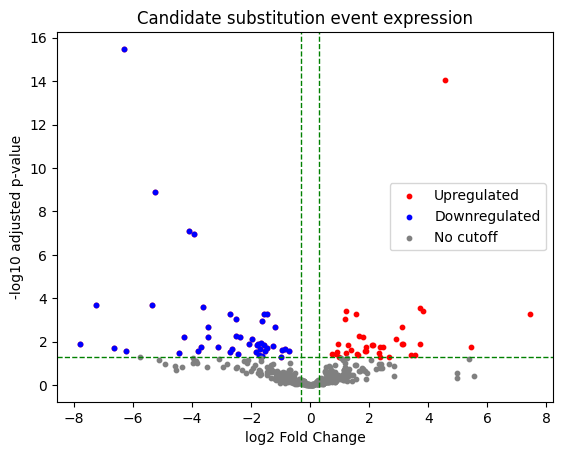

In [ ]:
## Running DE modules on healthy kideney tissues and RCC tissue, all independent patients

# Opens up zip files (import gz files into local directory)
files1 = '/content/SRR11873712.fastq.gz'
files2 = '/content/SRR11873715.fastq.gz'
files3 = '/content/SRR11873716.fastq.gz'
files4 = '/content/SRR11873709.fastq.gz'
files5 = '/content/SRR11873710.fastq.gz'
files6 = '/content/SRR11873711.fastq.gz'
gz_files_list = [files1, files2, files3, files4, files5, files6]
expandGZ(gz_files_list)

# Trims the fastq files
adapter = 'TGGAATTCTCGGGTGCCAAGGAACTCCAG'
files1 = '/content/SRR11873712.fastq'
files2 = '/content/SRR11873715.fastq'
files3 = '/content/SRR11873716.fastq'
files4 = '/content/SRR11873709.fastq'
files5 = '/content/SRR11873710.fastq'
files6 = '/content/SRR11873711.fastq'
raw_files_list = [files1, files2, files3, files4, files5, files6]
trimmer(input_raw_files=raw_files_list, adapter=adapter, minLength=18, maxLength=25, adapter_Mismatch_Num=1, min_overlap_adapter_length=8, max_e_errors=0.0251)

# Collapses reads
files1 = '/content/trimmed_files_4_SRR11873712.fastq'
files2 = '/content/trimmed_files_5_SRR11873715.fastq'
files3 = '/content/trimmed_files_6_SRR11873716.fastq'
files4 = '/content/trimmed_files_1_SRR11873709.fastq'
files5 = '/content/trimmed_files_2_SRR11873710.fastq'
files6 = '/content/trimmed_files_3_SRR11873711.fastq'
trimmed_files_list = [files1, files2, files3, files4, files5, files6]
collapse_reads(trimmed_files_list)

# Run Bowtie 2 on collapsed files
hsa1_ref = species_reference('/content/mature.fa', 'hsa')
files1 = '/content/deduplicated_trimmed_files_4_SRR11873712.fasta'
files2 = '/content/deduplicated_trimmed_files_5_SRR11873715.fasta'
files3 = '/content/deduplicated_trimmed_files_6_SRR11873716.fasta'
files4 = '/content/deduplicated_trimmed_files_1_SRR11873709.fasta'
files5 = '/content/deduplicated_trimmed_files_2_SRR11873710.fasta'
files6 = '/content/deduplicated_trimmed_files_3_SRR11873711.fasta'
deduplicated_files_list = [files1, files2, files3, files4, files5, files6]
bowtie(deduplicated_files_list, hsa1_ref, seedLength=8, num_mismatch_in_seed=1, num_return_align=1, align_style='end-to-end')

# Runs PyDESeq2 on the given SAM files
sam1 = '/content/bowtie1.sam'
sam2 = '/content/bowtie2.sam'
sam3 = '/content/bowtie3.sam'
sam4 = '/content/bowtie4.sam'
sam5 = '/content/bowtie5.sam'
sam6 = '/content/bowtie6.sam'
bowties_files = [sam1, sam2, sam3, sam4, sam5, sam6]
postBowtie2(bowties_files)
aligned_genes = finding_total_aligned(count_csv)
Deseq2('/content/count_data_DE.csv', '/content/metadata_DE.csv', 'Counts', list(aligned_genes.values))

In [ ]:
#files1 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/CON/SRR11873712.fastq.gz'
#files2 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/CON/SRR11873715.fastq.gz'
#files3 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/CON/SRR11873716.fastq.gz'
#files4 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/HIGH/SRR11873709.fastq.gz'
#files5 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/HIGH/SRR11873710.fastq.gz'
#files6 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/HIGH/SRR11873711.fastq.gz'

In [ ]:
df = pd.read_csv('/content/stats_res.csv', index_col=0)
lists = np.array(df['log2FoldChange'])
# Counts how many upregulated and down regulated genes in the positive control samples
countPositive = np.sum(lists > 0)
countNegative = np.sum(lists < 0)
print(countPositive)
print(countNegative)

# Writes a csv file to determine if the genes selected for viewing are present
lists = ['hsa-miR-200c-3p', 'hsa-miR-362-5p', 'hsa-miR-363-3p', 'hsa-miR-204-5p', 'hsa-miR-21-5p', 'hsa-miR-224-5p', 'hsa-miR-155-5p', 'hsa-miR-210-3p']
df = df[df.index.isin(lists)]
df.to_csv('focusGenes.csv', index=True)


37
45


# Candidate mutation detection specific code

In [ ]:
numOfSeq = [10576239, 7175812, 7223056, 8721250, 9390432, 11197628]
aligned_num_of_seq = [7340037,4812242,4840689,6044101,6327341,7794164]
Q_avg_error_probs =[0.001, 0.001, 0.00025694336894812724, 0.001, 0.001, 0.001]
length_distribution = [{18: 28633, 19: 322755, 20: 794461, 21: 1981129, 22: 3359301, 23: 719447, 24: 125014, 25: 9296}, {18: 17621, 19: 220529, 20: 506825, 21: 1364808, 22: 2164752, 23: 461543, 24: 69986, 25: 6178}, {18: 11004, 19: 230980, 20: 409566, 21: 1262299, 22: 2346452, 23: 500209, 24: 71923, 25: 8259}, {18: 18980, 19: 261804, 20: 611172, 21: 1637676, 22: 2843694, 23: 580827, 24: 83678, 25: 6270}, {18: 20495, 19: 297052, 20: 561490, 21: 1725623, 22: 2938684, 23: 692322, 24: 81933, 25: 9742}, {18: 32481, 19: 306622, 20: 849542, 21: 2259545, 22: 3536461, 23: 724145, 24: 75583, 25: 9785}]

In [ ]:
sam1 = '/content/bowtie1.sam'
sam2 = '/content/bowtie2.sam'
sam3 = '/content/bowtie3.sam'
sam4 = '/content/bowtie4.sam'
sam5 = '/content/bowtie5.sam'
sam6 = '/content/bowtie6.sam'
sam_files = [sam1, sam2, sam3, sam4, sam5, sam6]
totalAlignedCounts = samAnalyzer(sam_files, aligned_num_of_seq) # Call samAnalyzer to determine candidate substitution events

In [ ]:
import pandas as pd

# Load the normalized and raw mutation data CSV files
df_normalized = pd.read_csv('all_mutations_combined.csv')
df_raw = pd.read_csv('all_mutations_combined_raw.csv')

# Rename columns to clearly indicate normalized or raw counts, excluding the identifier columns
control_high_cols_normalized = [col for col in df_normalized.columns if col not in ['miRNA', 'Position', 'Ref_to_Alt']] #
control_high_cols_raw = [col for col in df_raw.columns if col not in ['miRNA', 'Position', 'Ref_to_Alt']]

df_normalized.rename(columns={col: col + '_normalized' for col in control_high_cols_normalized}, inplace=True) # Adds '_normalized' to the end of the column(s) containing counts of candidate events
df_raw.rename(columns={col: col + '_raw' for col in control_high_cols_raw}, inplace=True) # Adds '_raw' to the end of the column(s) containing counts of candidate events

# Merge the two DataFrames on the identifier columns
df_combined_output = pd.merge(df_normalized, df_raw, on=['miRNA', 'Position', 'Ref_to_Alt'], how='outer')

# Create the single combined identifier column
df_combined_output['Mutation_Identifier'] = df_combined_output['miRNA'].astype(str) + ' | ' + \
                                            df_combined_output['Position'].astype(str) + ' | ' + \
                                            df_combined_output['Ref_to_Alt'].astype(str)

# Drop the original individual identifier columns
df_combined_output.drop(columns=['miRNA', 'Position', 'Ref_to_Alt', 'Control1_normalized', 'Control2_normalized',  'Control3_normalized', 'High1_normalized', 'High2_normalized', 'High3_normalized'], inplace=True)

# Reorder columns to have the new identifier column first
all_columns = ['Mutation_Identifier'] + [col for col in df_combined_output.columns if col != 'Mutation_Identifier']
df_combined_output = df_combined_output[all_columns]

# Fill NaN values (where a mutation is not present in a specific sample) with 0
df_combined_output.fillna(0, inplace=True)
df_combined_output.columns = ['Mutation_Identifier', 'Control1', 'Control2', 'Control3', 'High1', 'High2', 'High3']
# Save the combined DataFrame to a new CSV file without writing the pandas index as a column
df_combined_output.to_csv('all_mutations_combined_single_column_id.csv', index=False)

print('Saved combined normalized and raw mutation data with single identifier column to all_mutations_combined_single_column_id.csv')
display(df_combined_output.head())

In [ ]:
# Recording substitution event counts, independent of position and particular sequence
df = pd.read_csv('all_mutations_combined.csv', index_col = 2)
df.drop(columns=['Position', 'miRNA'])
df = df.groupby('Ref_to_Alt', as_index=True).sum()
df.to_csv('adjustedBowtie1_events.csv', index=True)

In [ ]:
# Z-score heat maps of candidate substitution events, independent of
zscore_all_samples = [] # Gets the Z score of each column
df = pd.read_csv('/content/adjustedBowtie1_events.csv', index_col=0)
dfzscores = pd.DataFrame(index =list(df.index) , columns=list(df.columns)) # List of all Z-scores

for samples in df.columns: #
  data = np.array(list(df.loc[:, samples])) # Sets up array
  z_scores = stats.zscore(data) # Calculates Z-score
  zscore_all_samples.append(z_scores) # Appends to list of all Z-scores
  dfzscores[samples] = z_scores # Sets a column with the values of Z-scores

# Sets the zscore events
df = dfzscores
df.index.name = 'Events' # Sets index column name

# Plots figures and sets heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    df,
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    linecolor="black",
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Z-score"}
)
plt.title("Mutation Event Z-score Heatmap")
plt.xlabel("Samples")
plt.ylabel("Mutation Type")
plt.tight_layout()
plt.show()

Index(['Control1', 'Control2', 'Control3', 'High1', 'High2', 'High3'], dtype='object')
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 13.98 seconds.

Fitting dispersion trend curve...
/usr/local/lib/python3.12/dist-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.35 seconds.

Fitting MAP dispersions...
... done in 20.76 seconds.

Fitting LFCs...
... done in 14.02 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 4.10 seconds.



Log2 fold change & Wald test p-value: Types High vs Control
                           baseMean  log2FoldChange     lfcSE      stat  \
Mutation_Identifier                                                       
mmu-let-7a-1-3p | 1 | C-T  0.144766       -1.189417  4.428321 -0.268593   
mmu-let-7a-1-3p | 4 | T-C  0.204820       -1.189417  4.428321 -0.268593   
mmu-let-7a-1-3p | 5 | A-G  0.184545        0.734157  4.428352  0.165786   
mmu-let-7a-1-3p | 7 | A-C  0.334935        1.739860  3.227132  0.539135   
mmu-let-7a-1-3p | 7 | A-G  0.123912        0.734157  4.428352  0.165786   
...                             ...             ...       ...       ...   
mmu-miR-9b-3p | 20 | G-T   3.506356        5.164102  4.213122  1.225719   
mmu-miR-9b-3p | 21 | A-C   0.970648        3.307047  3.417443  0.967696   
mmu-miR-9b-3p | 21 | A-G   3.549221        0.866751  1.148816  0.754473   
mmu-miR-9b-3p | 21 | A-T   4.271432       -0.943306  1.851387 -0.509513   
mmu-miR-9b-5p | 3 | C-T    0.334935     

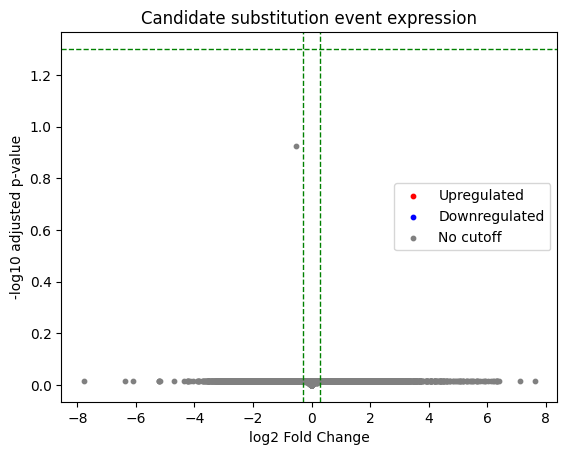

In [ ]:
# PyDESeq2 analysis on individual mutation event groups
aligned_genes = [7340037, 4812242, 4840689, 6044101, 6327341, 7794164]
Deseq2('/content/all_mutations_combined_single_column_id.csv', '/content/metadata_DE.csv', 'Sub', list(aligned_genes.values))

In [ ]:
# Random selection of 50 internal isomir genes to select for a 1 million seq sample
import random
sequences = [
    "TGAGGTGGTAGGTTGTATAGTT",
    "TATTGCACTTGCCCCGGCCTGT",
    "TATTGCGCTTGTCCCGGCCTGT",
    "TGTTGCACTTGTCCCGGCCTGT",
    "TACTGCACTTGTCCCGGCCTGT",
    "TATTGCACTTGTCCCGACCTGT",
    "TATTGCACTTGTCCCAGCCTGT",
    "TATTGCACTTGTCCCGGCCCGT",
    "CGAGGTAGTAGGTTGTATAGTT",
    "CATTGCACTTGTCCCGGCCTGT",
    "AAGCTGCCAGTTGAAGAATTGT",
    "TGAGGTAGTAGGTTGTATAGCT",
    "TATTGCACTTGTCACGGCCTGT",
    "AAGCTGCTAGTTGAAGAACTGT",
    "AATTGCACTTGTCCCGGCCTGT",
    "GAGCTGCCAGTTGAAGAACTGT",
    "TATTGCACTTGTCTCGGTCTGA",
    "TATTGCACTTGTCCCTGCCTGT",
    "AGGCTGCCAGTTGAAGAACTGT",
    "TGAGGGAGTAGGTTGTATAGTT",
    "TGAGGTAGTAGGTCGTATAGTT",
    "TATTACACTTGTCCCGGCCTGT",
    "AAGCTGTCAGTTGAAGAACTGT",
    "TCTCACTGTAGCATCGAACCCC",
    "TATTGCACTTGTCCCGGTCTGT",
    "AAGCTGCCAGTCGAAGAACTGT",
    "TGAGGCAGTAGATTGTATAGTT",
    "AAGCCGCCAGTTGAAGAACTGT",
    "AAGCTGCCAGTTGAGGAACTGT",
    "AAGCTGCCGGTTGAAGAACTGT",
    "CATTGCACTTGTCTCGGCCTGA",
    "TGAGGGAGTAGATTGTATAGTT",
    "TGAGGAAGTAGGTTGTATAGTT",
    "AAGCTGCCAGTTGGAGAACTGT",
    "AAGCTGCCAGCTGAAGAACTGT",
    "AAGCTGCCAGTTGAAGGACTGT",
    "AAGCTACCAGTTGAAGAACTGT",
    "TAAGGTAGTAGGTTGTATAGTT",
    "TATTGCACTTGTCCAGGCCTGT",
    "TATTGCACTTATCCCGGCCTGT",
    "TATTGCACTTGTTCCGGCCTGT",
    "TATTGCACTTGTCTCGGCCTGT",
    "TGGGGTAGTAGGTTGTATAGTT",
    "TGAGGTAGTAGGCTGTATAGTT",
    "TATTGCACTTGTCCTGGCCTGT",
    "TGAGGCAGTAGGTTGTATAGTT",
    "TATTGTACTTGTCCCGGCCTGT",
    "TATCGCACTTGTCCCGGCCTGT",
    "TATTGCACTTGTCCCGGCCTAT",
    "TGAGGTAGTGGGTTGTATAGTT"
] # 50 internal isomirs, with one substitution event per sequence
num = 1
# Random selection process
with open('testSNVfasta.fasta', 'w') as f:
  for i in range(1, 1000001):
    f.write(f'>Seq{num}\n{random.choice(sequences)}\n')
    num += 1

In [ ]:
# Bowtie on the artificial fasta files
bowtie(['/content/isomirTestFile.fasta'], '/content/hsaMaturemiRNA.fasta')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
# Replace 'My Drive/Your_Folder_Name' with your actual Drive path
path = "/content/drive/My Drive/Your_Folder_Name"
os.chdir(path)
print("Current directory:", os.getcwd())

In [ ]:
files1 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/CON/SRR11873712.fastq'
files2 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/CON/SRR11873715.fastq'
files3 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/CON/SRR11873716.fastq'
files4 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/HIGH/SRR11873709.fastq'
files5 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/HIGH/SRR11873710.fastq'
files6 = '/content/drive/MyDrive/microplastics-miRNA-project/rawData/GSE159881/HIGH/SRR11873711.fastq'
raw_files_list = [files1, files2, files3, files4, files5, files6]
fqstQC(raw_files_list, '/content/fastqc_output')

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fastqc is already the newest version (0.11.9+dfsg-5).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
Started analysis of SRR11873712.fastq
Approx 5% complete for SRR11873712.fastq
Approx 10% complete for SRR11873712.fastq
Approx 15% complete for SRR11873712.fastq
Approx 20% complete for SRR11873712.fastq
Approx 25% complete for SRR11873712.fastq
Approx 30% complete for SRR11873712.fastq
Approx 35% complete for SRR11873712.fastq
Approx 40% complete for SRR11873712.fastq
Approx 45% complete for SRR11873712.fastq
Approx 50% complete for SRR11873712.fastq
Approx 55% complete for SRR11873712.fastq
Approx 60% complete for SRR11873712.fastq
Approx 65% complete for SRR11873712.fastq
Approx 70% complete for SRR11873712.fastq
Approx 75% complete for SRR11873712.fastq
Approx 80% complete for SRR11873712.fastq
Approx 85% complete for SRR11873712.fastq
Approx 90% complete for SRR11873712